# EE473 Final Project: Energy-Aware Edge Scheduling with Reinforcement Learning

Zilong Zeng & Meng Wu


## 1) Problem Setup

This project studies energy-aware edge scheduling as a sequential decision problem with three actions: `low`, `medium`, and `high`.
At each step, workload arrives from a real trace, the controller selects an action, and the system updates queue and battery states.
The objective combines operating cost and service quality through
`r_t = -(alpha_energy * energy_t + beta_latency * latency_t + gamma_miss * miss_t)`.
Default weights are `(alpha, beta, gamma) = (1.0, 0.6, 2.0)`.

## 2) Dataset and Evaluation Protocol

- Source: Google cluster task-event trace (`120` shards)
- Preprocess: submit-event aggregation, workload normalization, train/test split
- Episode length: `288`
- Main protocol: `20` train episodes + `6` non-overlap test episodes
- Compared methods: heuristic baselines, tabular Q-learning, linear approximation Q-learning
- Reporting rule: 5 seeds with mean/std for final claims

With protocol fixed, we instantiate the simulation environment shared by all experiments.

## 3) Environment Setup

All methods share the same custom scheduling simulator, so the environment definition is central to fair comparison.

State and action setting:
- Observation is a discretized tuple `(workload_bin, queue_bin, battery_bin)`.
- Action selects one operating mode: `low`, `medium`, or `high`.

Per-step dynamics (consistent with `src/env.py`):
- Arrival is trace workload at the current time step (`arrival = workload_norm * workload_scale`).
- Service depends on action (`service_rates`) and cannot exceed available demand.
- Queue update: `queue_{t+1} = clip(queue_t + arrival_t - service_t, 0, max_queue)`.
- Energy model: `energy_t = energy_cost(action_t) + switch_cost * I[action_t != action_{t-1}]`.
- Battery update: `battery_{t+1} = max(0, battery_t - energy_t)`.
- Latency proxy is next-step queue level; miss indicator is triggered when queue exceeds `deadline_queue_threshold`.

Operational meaning:
- `energy` = operating cost of chosen mode and switching,
- `latency` = backlog-induced service delay proxy,
- `miss` = deadline-threshold violation event.

Because the controller repeatedly allocates limited service capacity under stochastic arrivals and explicit constraints, this is a scheduling control problem.


In [1]:
from pathlib import Path
import sys
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
if not (ROOT / 'scripts').exists():
    ROOT = ROOT.parent
assert (ROOT / 'scripts').exists(), f'Expected repo root at {ROOT}'
SRC = ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from config import DEFAULT_ENV_CONFIG
from data_loader import load_workload_trace, build_episodes
from env import EnergySchedulingEnv

TRACE_PATH = ROOT / 'data/processed/workload_trace_120.csv'
EPISODE_LENGTH = 288
STRIDE = 288

train_series = load_workload_trace(TRACE_PATH, split='train')
test_series  = load_workload_trace(TRACE_PATH, split='test')

train_episodes = build_episodes(train_series, EPISODE_LENGTH, stride=STRIDE)[:20]
test_episodes  = build_episodes(test_series,  EPISODE_LENGTH, stride=STRIDE)[:6]

print(f"Train episodes : {len(train_episodes)}  ×  {len(train_episodes[0])} steps")
print(f"Test  episodes : {len(test_episodes)}  ×  {len(test_episodes[0])} steps")
print(f"Workload range : [{min(train_series):.3f}, {max(train_series):.3f}]")

Train episodes : 20  ×  288 steps
Test  episodes : 6  ×  288 steps
Workload range : [0.000, 1.000]


## 4) Baseline Evaluation

We first evaluate fixed policies (`always_low`, `always_medium`, `always_high`, threshold rules) on held-out test episodes.
This establishes a reference point and identifies the strongest heuristic baseline that RL must beat.

In [2]:
import pandas as pd
from baselines import (
    always_low_policy, always_medium_policy, always_high_policy,
    threshold_policy_factory, evaluate_policy,
)

baseline_policies = {
    'always_low': always_low_policy,
    'always_medium': always_medium_policy,
    'always_high': always_high_policy,
    'threshold(w=0.60)': threshold_policy_factory(workload_threshold=0.60),
    'threshold(w=0.80)': threshold_policy_factory(workload_threshold=0.80),
}

baseline_results = {}
rows = []
for name, policy in baseline_policies.items():
    m = evaluate_policy(test_episodes, policy, config=DEFAULT_ENV_CONFIG)
    baseline_results[name] = m
    rows.append({
        'Policy': name,
        'Avg Return': round(m['avg_episode_return'], 3),
        'Energy': round(m['avg_step_energy'], 4),
        'Latency': round(m['avg_step_latency'], 4),
        'Miss Rate': round(m['miss_rate'], 4),
    })

baseline_df = pd.DataFrame(rows).sort_values('Avg Return', ascending=False).reset_index(drop=True)
display(baseline_df)

,Policy,Avg Return,Energy,Latency,Miss Rate
0,always_low,-57.289,0.1800,0.0315,0.0
1,threshold(w=0.80),-57.390,0.1951,0.0069,0.0
2,threshold(w=0.60),-58.512,0.2022,0.0016,0.0
3,always_medium,-121.749,0.4200,0.0046,0.0
4,always_high,-244.800,0.8500,0.0000,0.0


## 5) RL Training

We run tabular Q-learning and linear approximation Q-learning once to verify end-to-end training behavior.
These single-seed outputs are diagnostic only.

Scope note on algorithm class:
- The project follows the course-recommended path (tabular methods + function approximation).
- We do not add an extra deep RL model here to avoid changing scope late in submission.
- A DQN-style extension is treated as future work rather than retrofitted evidence.


In [3]:
import time
from q_learning import QLearningConfig, train_tabular_q_learning

# Tabular Q-learning
tabular_cfg = QLearningConfig(
    num_epochs=300,
    alpha=0.15,
    gamma=0.98,
    epsilon_start=0.30,
    epsilon_end=0.02,
    epsilon_decay=0.995,
    eval_every=5,
    seed=42,
)

t0 = time.perf_counter()
tabular_result = train_tabular_q_learning(
    train_episodes=train_episodes,
    test_episodes=test_episodes,
    env_config=DEFAULT_ENV_CONFIG,
    algo_config=tabular_cfg,
)
tabular_time = time.perf_counter() - t0

bm = tabular_result['best_test_metrics']
print(f"Tabular Q: return={bm['avg_episode_return']:.3f}, time={tabular_time:.2f}s")

Tabular Q: return=-56.217, time=6.59s


In [4]:
from approx_q import ApproxQLearningConfig, train_linear_approx_q_learning

# Linear Approximation Q-learning
approx_cfg = ApproxQLearningConfig(
    num_epochs=300,
    alpha=0.02,
    gamma=0.98,
    epsilon_start=0.30,
    epsilon_end=0.02,
    epsilon_decay=0.997,
    eval_every=5,
    seed=42,
)

t0 = time.perf_counter()
approx_result = train_linear_approx_q_learning(
    train_episodes=train_episodes,
    test_episodes=test_episodes,
    env_config=DEFAULT_ENV_CONFIG,
    algo_config=approx_cfg,
)
approx_time = time.perf_counter() - t0

bm = approx_result['best_test_metrics']
print(f"Approx Q: return={bm['avg_episode_return']:.3f}, time={approx_time:.2f}s, feature_dim={int(approx_result['feature_dim'])}")

Approx Q: return=-55.923, time=26.54s, feature_dim=66


## 6) Main Results

This section is the primary evidence for final conclusions.
Protocol: seeds `11, 22, 33, 44, 55`, `120` shards, `20` train + `6` non-overlap test episodes (`episode_length=288`, `stride=288`).
All reported metrics are mean ± std across seeds.

Interpretation is conservative: gains are consistent but incremental, the strongest baseline is already competitive, and tabular-vs-approx mainly reflects a return-versus-training-cost trade-off.


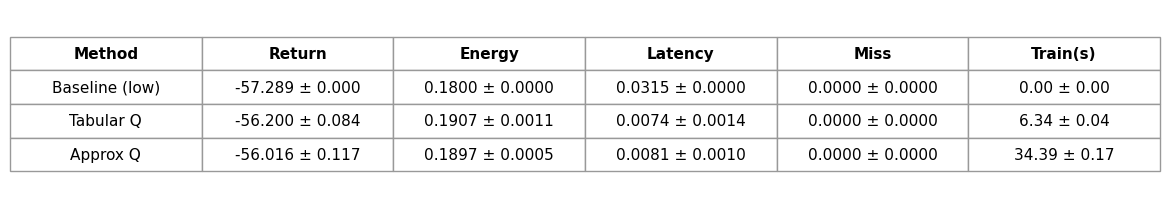

Summary: Tabular gain=+1.088, Approx gain=+1.272, time ratio=5.4x


In [5]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.image as mpimg

RESULTS = ROOT / 'results'
FIG_DIR = RESULTS / 'final_figures'

with open(RESULTS / 'phase3_multiseed_120.json') as f:
    ms = json.load(f)

def fmt(mean, std, digits=3):
    return f'{mean:.{digits}f} ± {std:.{digits}f}'

bm = ms['baseline']['best_test_metrics']
rows = [
    {
        'Method': 'Baseline (low)',
        'Return': fmt(bm['avg_episode_return'], 0.0),
        'Energy': fmt(bm['avg_step_energy'], 0.0, 4),
        'Latency': fmt(bm['avg_step_latency'], 0.0, 4),
        'Miss': fmt(bm['miss_rate'], 0.0, 4),
        'Train(s)': '0.00 ± 0.00',
    }
]
for key, label in [('tabular', 'Tabular Q'), ('approx', 'Approx Q')]:
    ag = ms[key]['aggregate_best_test_metrics']
    rows.append({
        'Method': label,
        'Return': fmt(ag['avg_episode_return']['mean'], ag['avg_episode_return']['std']),
        'Energy': fmt(ag['avg_step_energy']['mean'], ag['avg_step_energy']['std'], 4),
        'Latency': fmt(ag['avg_step_latency']['mean'], ag['avg_step_latency']['std'], 4),
        'Miss': fmt(ag['miss_rate']['mean'], ag['miss_rate']['std'], 4),
        'Train(s)': fmt(ag['training_wall_time_sec']['mean'], ag['training_wall_time_sec']['std'], 2),
    })

main_results_df = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(11.8, 2.2))
ax.axis('off')
tbl = ax.table(
    cellText=main_results_df.values,
    colLabels=main_results_df.columns,
    loc='center',
    cellLoc='center',
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1.0, 1.8)
for (r, cidx), cell in tbl.get_celld().items():
    cell.set_edgecolor('#999999')
    if r == 0:
        cell.set_text_props(weight='bold')
plt.tight_layout()
plt.show()

tab_ret = ms['tabular']['aggregate_best_test_metrics']['avg_episode_return']
apx_ret = ms['approx']['aggregate_best_test_metrics']['avg_episode_return']
tab_t = ms['tabular']['aggregate_best_test_metrics']['training_wall_time_sec']
apx_t = ms['approx']['aggregate_best_test_metrics']['training_wall_time_sec']
print(f"Summary: Tabular gain={tab_ret['mean']-bm['avg_episode_return']:+.3f}, "
      f"Approx gain={apx_ret['mean']-bm['avg_episode_return']:+.3f}, "
      f"time ratio={apx_t['mean']/tab_t['mean']:.1f}x")

### Main Figure

The learning-curve figure summarizes convergence behavior and seed stability.
The accompanying result table shows that both RL methods consistently improve over the best heuristic baseline,
with Approx Q slightly better in return and Tabular Q substantially lower in training time.


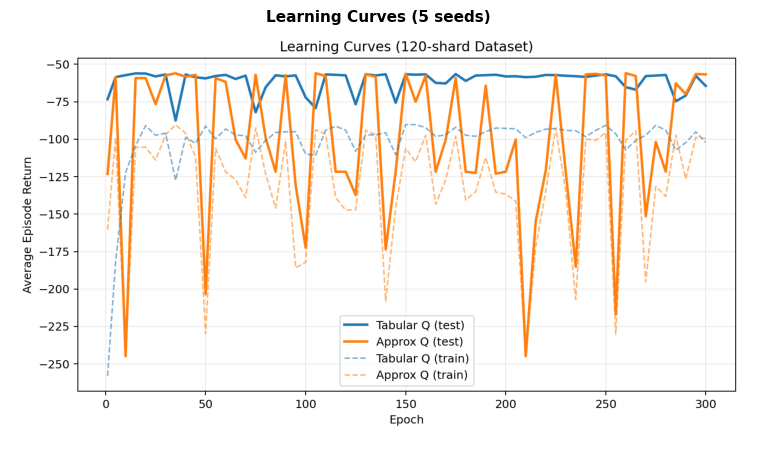

In [6]:
fig, ax = plt.subplots(1, 1, figsize=(10.5, 4.6))
ax.imshow(mpimg.imread(FIG_DIR / 'learning_curves_tabular_vs_approx.png'))
ax.axis('off')
ax.set_title('Learning Curves (5 seeds)', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

## 7) Additional Diagnostics

### 7a) Policy Behavior Diagnostics

This figure compares return gain over the best baseline against training cost.
It highlights the practical trade-off between marginal return improvement and computation time.

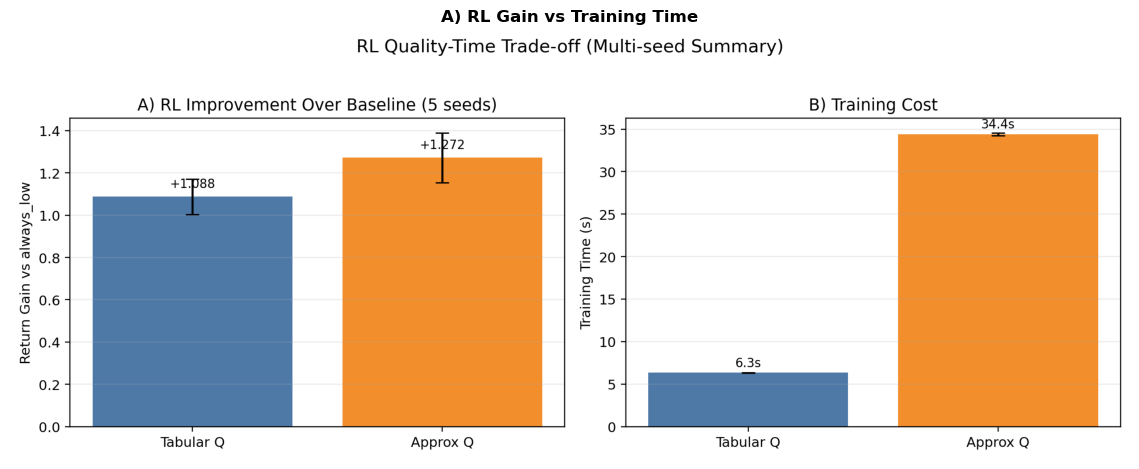

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(11.5, 4.8))
ax.imshow(mpimg.imread(FIG_DIR / 'rl_gain_vs_time.png'))
ax.axis('off')
ax.set_title('A) RL Gain vs Training Time', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 8) Sensitivity and Generalization

To validate robustness, we test reward sensitivity, hyperparameter sensitivity, and train/test slicing generalization.
These analyses are used to check consistency of conclusions, not to claim large extra gains.


### 8a) Reward-Weight Sensitivity

We vary reward weights and compare RL against `always_low` within each setting to avoid cross-scale ambiguity.
The goal is to test consistency of direction (RL advantage), not to maximize absolute magnitude.

In [8]:
with open(RESULTS / 'reward_sensitivity_context_120.json') as f:
    rs = json.load(f)

reward_rows = []
for r in rs['rows']:
    reward_rows.append({
        'Weights (alpha,beta,gamma)': f'({r["alpha_energy"]:.2f}, {r["beta_latency"]:.2f}, {r["gamma_miss"]:.2f})',
        'Method Return (mean±std)': f'{r["avg_episode_return_mean"]:.3f} ± {r["avg_episode_return_std"]:.3f}',
        'AlwaysLow Return': round(r['always_low_return'], 3),
        'Gap vs AlwaysLow': round(r['gap_vs_always_low'], 3),
        'Relative Gain (%)': round(r['relative_gain_pct'], 2),
    })

display(pd.DataFrame(reward_rows))

,"Weights (alpha,beta,gamma)",Method Return (mean±std),AlwaysLow Return,Gap vs AlwaysLow,Relative Gain (%)
0,"(1.00, 0.80, 2.00)",-56.463 ± 0.110,-59.105,2.642,4.47
1,"(0.80, 0.60, 2.00)",-45.098 ± 0.050,-46.921,1.822,3.88
2,"(1.00, 0.60, 2.00)",-56.027 ± 0.111,-57.289,1.262,2.20
3,"(1.20, 0.60, 2.00)",-66.996 ± 0.126,-67.657,0.661,0.98
4,"(1.00, 0.40, 2.00)",-55.397 ± 0.114,-55.472,0.075,0.14


### 8b) Hyperparameter Sensitivity

We sweep learning rate (`alpha`), epsilon decay, and discount factor (`gamma`).
Results are interpreted as neighborhood robustness: top settings should remain close rather than diverge sharply.

In [9]:
from collections import defaultdict

with open(RESULTS / 'hyperparam_sensitivity_120.json') as f:
    hp = json.load(f)

agg = defaultdict(list)
for rec in hp['records']:
    key = (rec['alpha'], rec['epsilon_decay'], rec['gamma'])
    for run in rec['runs']:
        agg[key].append(run['best_test_metrics']['avg_episode_return'])

rows = []
for (alpha, eps_decay, gamma), vals in agg.items():
    rows.append({
        'alpha': alpha,
        'epsilon_decay': eps_decay,
        'gamma': gamma,
        'Avg Return': round(float(np.mean(vals)), 3),
        'Std': round(float(np.std(vals)), 3),
        'Default Config': (alpha == 0.02 and eps_decay == 0.997 and gamma == 0.98),
    })

hp_df = pd.DataFrame(rows).sort_values('Avg Return', ascending=False).reset_index(drop=True)
display(hp_df)

,alpha,epsilon_decay,gamma,Avg Return,Std,Default Config
0,0.030,0.999,0.98,-56.017,0.144,False
1,0.020,0.997,0.98,-56.027,0.111,True
2,0.020,0.997,0.95,-56.063,0.141,False
3,0.015,0.995,0.98,-56.217,0.314,False
4,0.020,0.997,0.99,-56.267,0.265,False


Ablation curves corresponding to the reward-weight and hyperparameter tables are shown below.

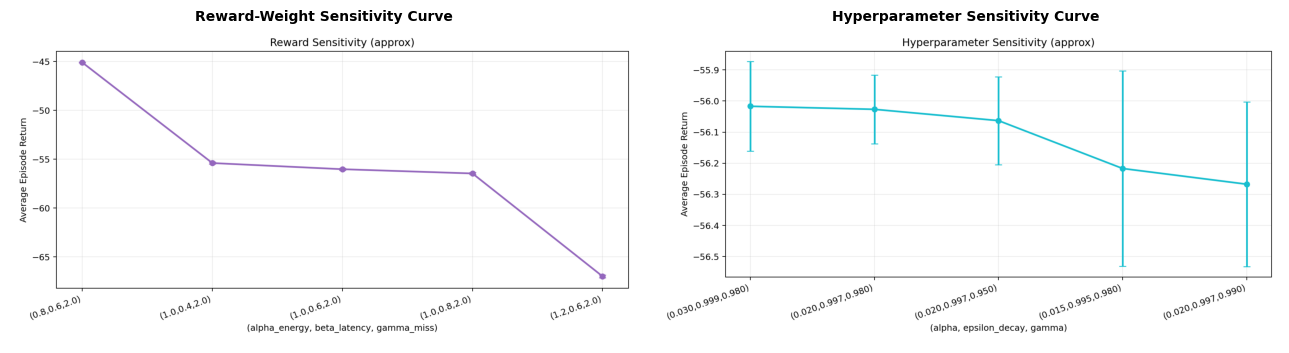

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
for ax, fname, title in [
    (axes[0], 'reward_sensitivity_return.png', 'Reward-Weight Sensitivity Curve'),
    (axes[1], 'hyperparam_sensitivity_return.png', 'Hyperparameter Sensitivity Curve'),
]:
    ax.imshow(mpimg.imread(FIG_DIR / fname))
    ax.axis('off')
    ax.set_title(title, fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()

### 8c) Train/Test Slicing Generalization

We compare two slicing strategies to check whether performance depends on one specific partition.
Comparable outcomes across slices support limited but meaningful generalization.

In [11]:
with open(RESULTS / 'generalization_check_120.json') as f:
    gc = json.load(f)

rows = []
for rec in gc['records']:
    rets = [r['best_test_metrics']['avg_episode_return'] for r in rec['runs']]
    engs = [r['best_test_metrics']['avg_step_energy'] for r in rec['runs']]
    lats = [r['best_test_metrics']['avg_step_latency'] for r in rec['runs']]
    miss = [r['best_test_metrics']['miss_rate'] for r in rec['runs']]
    rows.append({
        'Setting': rec['setting']['name'],
        'Train/Test': f"{rec['num_train_episodes']}/{rec['num_test_episodes']}",
        'Return (mean±std)': f"{np.mean(rets):.3f} ± {np.std(rets):.3f}",
        'Energy': round(float(np.mean(engs)), 4),
        'Latency': round(float(np.mean(lats)), 4),
        'Miss Rate': round(float(np.mean(miss)), 4),
    })

display(pd.DataFrame(rows))

,Setting,Train/Test,Return (mean±std),Energy,Latency,Miss Rate
0,non_overlap,20/6,-45.348 ± 0.406,0.1924,0.0059,0.0
1,overlap_test,20/10,-45.709 ± 0.400,0.1933,0.0068,0.0


## 9) Answers to Questions

### 1) How do the algorithms perform in terms of training time?
Under the 5-seed protocol, tabular Q-learning trains in about **6.3 s**, while linear approximation Q-learning trains in about **34.4 s**. This corresponds to an approximate **5.4x** time gap. The timing difference is large and consistent across seeds, so it is a practical deployment consideration.

### 2) How close are the results to expected results?
The expected pattern was that RL should outperform heuristic control while remaining in a narrow margin because `always_low` is already strong on this workload. Observed results match that expectation: tabular and approximate Q both improve average return by roughly **+1.1 to +1.3** over `always_low`. The gains are consistent but incremental, which is aligned with a competitive baseline setting.

### 3) How were parameters adjusted to solve the problem?
We used structured sweeps over reward weights and key RL hyperparameters (`alpha`, `epsilon_decay`, `gamma`) instead of single-point tuning. The default configuration was retained because it remained near the top-performing neighborhood in the hyperparameter table. This approach prioritizes stable behavior over aggressive overfitting to one split.

### 4) What parameters played an important role?
Reward weighting, especially `beta` (latency weight), materially changes the return scale and the energy-latency balance. For tabular learning, discretization granularity is also important because it controls the coverage-versus-noise trade-off in value updates. These parameters affect reliability more than any single random seed choice.

### 5) What were the challenges when working with the algorithms?
A primary challenge was balancing discretization detail and sample efficiency in the tabular method. Another challenge was calibrating reward terms so energy savings did not dominate latency and miss behavior. We also needed stricter deadline stress settings to make miss-rate differences visible.

### 6) How could results be improved in future work?
Future improvements should focus on harder workload slices, stricter service constraints, and broader state/action settings. Multi-device coordination and stronger function approximators are realistic next steps. Constrained RL formulations are also promising if SLA guarantees become a hard requirement.

### Trials and Setbacks During Development

- Early tabular bins were too coarse, causing unstable policy updates; we refined discretization to balance coverage and variance.
- Initial reward weights overemphasized energy and hurt latency; reward-weight ablations were used to recalibrate trade-offs.
- Under loose deadline thresholds, miss-rate gaps were hard to observe; stricter stress checks made differences visible.
- Single-seed outcomes could look optimistic; final claims were therefore anchored to 5-seed reporting.

## 10) Conclusion and Future Work

This project built a custom trace-driven edge scheduling simulator and compared heuristic baselines against tabular and linear-approximation Q-learning under a fixed 5-seed protocol.
Empirically, both RL methods consistently outperform the strongest heuristic baseline, but the margin is modest because that baseline is already competitive.
The main practical takeaway is a return-versus-training-cost trade-off: Approx Q gives slightly better return, while Tabular Q trains much faster.
Realistic extensions include adding a DQN-style deep RL baseline, evaluating harder workload slices with stricter service constraints, and extending from single-device to coordinated multi-device control.
